# 26년 1학기 머신러닝 이해와활용 기말과제(분류모형)
- 과제내용: 본인이 원하는 분석 주제를 정하고, 파이썬 라이브러리를 이용하여 데이터분석 및 시각화 결과를 제출
  - 회귀모델의 평가는 RMSE 사용
  - 분류모델의 평가는 balanced accuracy 사용


  - 분석 환경 설정
    - 학기 실습폴더 ML_2601 내에 term_paper_학번 이라는 이름의 폴더 생성
    - term_paper_학번 폴더 내에 data, output 폴더 각각 생성
      - 분석에 사용하는 모든 데이터 파일은 data 폴더에 넣을 것
      - 분석 과정에서 생성된 모든 파일과 챠트 이미지는 output 폴더에 저장할 것
  - 주의사항
    - 제출한 ipynb 파일이 함께 제출한 데이터를 이용하여 처음부터 끝까지 오류없이 실행되어야함
    - ChatGPT 등 AI의 도움을 받아 작성해도 됨. 단, 작성한 코드를 사용한 목적과 그 코드가 어떻게 동작한 것인지에 대한 설명이 있어야함.
    - 강의시간에 배우지 않은 코드와 함수를 사용하는 경우에도 코드에 대한 설명이 주석에 있어야 인정됨  
  - 과제 제출
    - 6월 10일(수) 23시 59분까지 LMS 과제 게시판에 제출
    - 제출파일: term_paper_학번 폴더 전체 압축파일
      - 전체코드를 html로 변환한 파일도 함께 제출
      - 보고서 ppt 파일
      - ppt 발표 녹화 영상(15분이내)


# 의사결정나무를 이용한 딥페이크 이미지 탐지 분류모델 만들기
- 제출자
  - 학번: 202155020
  - 이름: 정지훈
- 분석 시나리오:
  - 이미지 속성 피쳐를 이용하여 딥페이크 이미지를 탐지하는 분류모델을 만들기
  - 의사결정나무 알고리즘을 이용하며, 모델 평가는 balanced accuracy 사용


# START


## 구글 드라이브 연결


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 현재 작업폴더 확인
import os
os.getcwd()


'/content/drive/My Drive/ML_2601/term_paper_202155020'

In [ ]:
# 실습폴더 설정하기
os.chdir('/content/drive/MyDrive/ML_2601/term_paper_202155020')
os.getcwd() # 작업폴더가 잘 바뀌었는지 다시 한번 확인


'/content/drive/MyDrive/ML_2601/term_paper_202155020'

In [ ]:
# 작업폴더내 폴더 및 파일 확인
print(os.listdir())


['output', 'data', 'ML_2601_Deep_Fake.html', 'ML_2601_Deep_Fake.ipynb']


# 라이브러리 불러오기


In [ ]:
# 판다스 라이브러리 불러오기
import pandas as pd


In [ ]:
# 그래프에서 한글 폰트를 사용할 수 있게 해주는 koreanize_matplotlib 패키지 설치
# -q 옵션: 설치 로그 출력 최소화 → 셀 실행 속도 체감 향상
!pip install koreanize-matplotlib -q


In [ ]:
# koreanize-matplotlib 패키지 불러오기
import koreanize_matplotlib

# 그려진 그래프의 옵션들을 조정하기 위해 matplotlib의 pyplot 모듈을 plt라는 이름으로 불러옴
import matplotlib.pyplot as plt
plt.rc('axes', unicode_minus=False) # 그림에서 음수(-)가 나오도록 하는 옵션

# 그래프를 그리기 위한 seaborn 라이브러리 불러오기
import seaborn as sns


# 데이터 설명
- 딥페이크 이미지 탐지를 위한 이미지 URL 데이터셋
  - REAL: 실제 인물 이미지
  - FAKE: AI가 생성한 가짜 이미지(딥페이크)
- 데이터 포함된 각 열은 다음과 같음
  - image_id: 이미지 고유 번호
  - image_url: 이미지 URL
  - label: 이미지 종류 (REAL / FAKE)
  - label_numeric: 숫자형 레이블 (1=REAL, 0=FAKE)
  - category: 이미지 카테고리
  - gender: 성별
  - age_group: 연령대
  - source: 이미지 출처
  - fake_method: 딥페이크 생성 방법
  - image_quality: 이미지 품질
  - resolution: 해상도
  - confidence_score: 탐지 신뢰도 점수
  - detection_difficulty: 탐지 난이도


# Raw Data
- 데이터 불러오기
- 데이터 내용 확인


In [ ]:
import requests
import hashlib
import numpy as np
from PIL import Image
from io import BytesIO

df = pd.read_csv('./data/DEEPFAKE_DATASET.csv')
df.head()


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,2026-04-24,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,2026-04-04,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,2026-02-07,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-02-20,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,2026-04-12,v2.0,2026


In [ ]:
# 각 열의 자료형 확인
# 각 열의 결측치 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   object 
 2   label                 6557 non-null   object 
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   object 
 5   gender                6557 non-null   object 
 6   age_group             6557 non-null   object 
 7   source                6557 non-null   object 
 8   fake_method           3767 non-null   object 
 9   image_quality         6557 non-null   object 
 10  resolution            6557 non-null   object 
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   object 
 13  dataset_split         6557 non-null   object 
 14  date_collected        6557 non-null   object 
 15  version              

In [ ]:
df.describe()


,image_id,label_numeric,confidence_score,year
count,6557.00000,6557.000000,6557.000000,6557.0
mean,3279.00000,0.425499,0.903741,2026.0
std,1892.98719,0.494456,0.049982,0.0
min,1.00000,0.000000,0.800000,2026.0
25%,1640.00000,0.000000,0.860000,2026.0
50%,3279.00000,0.000000,0.910000,2026.0
75%,4918.00000,1.000000,0.950000,2026.0
max,6557.00000,1.000000,0.990000,2026.0


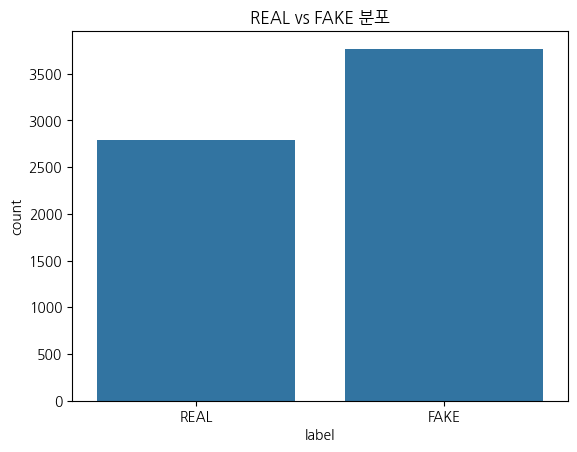

In [ ]:
# 예측대상(target)의 분포 확인
sns.countplot(data=df, x='label')
plt.title('REAL vs FAKE 분포')
plt.savefig('./output/label_distribution.png')
plt.show()


In [ ]:
# label별 label_numeric 확인
df.groupby('label')['label_numeric'].value_counts()


,,count
label,label_numeric,
FAKE,0,3767
REAL,1,2790


# 피쳐엔지니어링


## 이미지 다운로드 및 캐싱


In [ ]:
# 이미지를 저장할 캐시 폴더 생성
IMAGE_CACHE_DIR = './data/cached_images'
os.makedirs(IMAGE_CACHE_DIR, exist_ok=True)

# ThreadPoolExecutor: 여러 다운로드를 동시에 처리하는 병렬 처리 도구
# as_completed: 완료된 작업부터 순서대로 결과를 가져옴
# tqdm: 진행률 표시 도구
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

_session_local = threading.local()

def get_session():
    # 스레드별 requests.Session 재사용 (연결 풀 활용)
    # 매 요청마다 새 연결을 만들지 않아 속도가 빠름
    if not hasattr(_session_local, 'session'):
        s = requests.Session()
        s.headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})
        # Retry: 실패시 최대 3회 재시도, 서버 오류 코드 목록 지정
        retry = Retry(total=3, backoff_factor=0.5, status_forcelist=[429,500,502,503,504])
        s.mount('http://',  HTTPAdapter(max_retries=retry))
        s.mount('https://', HTTPAdapter(max_retries=retry))
        _session_local.session = s
    return _session_local.session

def download_image(url, cache_dir):
    # URL에서 이미지를 다운로드하여 로컬에 저장하는 함수
    # 이미 캐시된 파일은 즉시 반환 (재다운로드 없음)
    url_hash   = hashlib.md5(url.encode()).hexdigest()
    local_path = os.path.join(cache_dir, f'{url_hash}.jpg')
    if os.path.exists(local_path):
        return local_path
    try:
        session  = get_session()
        response = session.get(url, timeout=15)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img.save(local_path, 'JPEG', quality=90)
        return local_path
    except Exception:
        return None

# max_workers=16: I/O 바운드 작업은 CPU 수보다 많은 스레드가 효율적
MAX_WORKERS = 16
print(f'이미지 다운로드 중... (병렬 {MAX_WORKERS}개 스레드)')

local_paths = [None] * len(df)
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(download_image, url, IMAGE_CACHE_DIR): i
                     for i, url in enumerate(df['image_url'])}
    for future in tqdm(as_completed(future_to_idx), total=len(future_to_idx), desc='다운로드'):
        idx = future_to_idx[future]
        local_paths[idx] = future.result()

df['local_path'] = local_paths
df = df[df['local_path'].notna()].reset_index(drop=True)
print(f'\n유효 이미지 수: {len(df)}')
print(f'REAL: {(df["label_numeric"]==1).sum()}, FAKE: {(df["label_numeric"]==0).sum()}')


이미지 다운로드 중... (병렬 16개 스레드)


다운로드:   0%|          | 0/6557 [00:00<?, ?it/s]


유효 이미지 수: 5557
REAL: 2790, FAKE: 2767


## 피쳐 추출


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

def extract_rgb_features(img_path):
    # RGB 채널 간 상관관계 및 표준편차 피쳐 추출
    # 딥페이크 이미지는 채널 간 상관관계 패턴이 실제 이미지와 다를 수 있음
    try:
        img = np.array(Image.open(img_path).convert('RGB')).astype(np.float32)
        r = img[:, :, 0].flatten()
        g = img[:, :, 1].flatten()
        b = img[:, :, 2].flatten()
        corr_matrix = np.corrcoef([r, g, b])
        return {
            'rg_corr':     corr_matrix[0, 1],
            'rb_corr':     corr_matrix[0, 2],
            'gb_corr':     corr_matrix[1, 2],
            'r_std':       r.std(),
            'g_std':       g.std(),
            'b_std':       b.std(),
            'rg_diff_std': (r - g).std(),
            'rb_diff_std': (r - b).std(),
            'gb_diff_std': (g - b).std(),
        }
    except Exception:
        return None

MAX_WORKERS  = 8
paths        = df['local_path'].tolist()
rgb_features = [None] * len(paths)

print(f'RGB 피쳐 추출 중... (병렬 {MAX_WORKERS}개 스레드)')
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(extract_rgb_features, p): i
                     for i, p in enumerate(paths)}
    for future in tqdm(as_completed(future_to_idx), total=len(paths), desc='RGB 피쳐'):
        idx = future_to_idx[future]
        rgb_features[idx] = future.result()

rgb_df = pd.DataFrame(rgb_features, index=df.index)
df = pd.concat([df, rgb_df], axis=1)
df.dropna(subset=['rg_corr'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'완료! 데이터 수: {len(df)}')


RGB 피쳐 추출 중... (병렬 8개 스레드)


RGB 피쳐:   0%|          | 0/5557 [00:00<?, ?it/s]

완료! 데이터 수: 5557


In [ ]:
from scipy import ndimage
from scipy.stats import kurtosis

def extract_noise_features(img_path):
    # 가우시안 블러로 깨끗한 신호를 만들고 원본에서 빼서 노이즈를 분리
    # 딥페이크 이미지는 노이즈 패턴이 실제 이미지와 다를 수 있음
    try:
        img     = np.array(Image.open(img_path).convert('L')).astype(np.float32)
        blurred = ndimage.gaussian_filter(img, sigma=1.5)
        noise   = img - blurred
        signal_power = (blurred ** 2).mean()
        noise_power  = (noise  ** 2).mean()
        return {
            'noise_std':      noise.std(),
            'noise_energy':   noise_power,
            'noise_kurtosis': float(kurtosis(noise.flatten())),
            'noise_snr':      float(signal_power / (noise_power + 1e-8)),
        }
    except Exception:
        return None

MAX_WORKERS   = 8
paths         = df['local_path'].tolist()
noise_results = [None] * len(paths)

print(f'노이즈 피쳐 추출 중... (병렬 {MAX_WORKERS}개 스레드)')
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(extract_noise_features, p): i
                     for i, p in enumerate(paths)}
    for future in tqdm(as_completed(future_to_idx), total=len(paths), desc='노이즈 피쳐'):
        idx = future_to_idx[future]
        noise_results[idx] = future.result()

noise_df = pd.DataFrame(noise_results, index=df.index)
df = pd.concat([df, noise_df], axis=1)
print(f'완료! 추출된 피쳐: {list(noise_df.columns)}')


노이즈 피쳐 추출 중... (병렬 8개 스레드)


노이즈 피쳐:   0%|          | 0/5557 [00:00<?, ?it/s]

완료! 추출된 피쳐: ['noise_std', 'noise_energy', 'noise_kurtosis', 'noise_snr']


In [ ]:
def extract_texture_features(img_path):
    # Laplacian: 2차 미분으로 엣지 선명도 측정
    # Sobel: 1차 미분으로 x/y 방향 엣지 강도 계산
    try:
        img = np.array(Image.open(img_path).convert('L')).astype(np.float32)
        laplacian     = ndimage.laplace(img)
        laplacian_var = float(laplacian.var())
        sobel_x  = ndimage.sobel(img, axis=1)
        sobel_y  = ndimage.sobel(img, axis=0)
        edge_mag = np.sqrt(sobel_x**2 + sobel_y**2)
        threshold    = edge_mag.mean() + edge_mag.std()
        edge_density = float((edge_mag > threshold).mean())
        local_mean   = ndimage.uniform_filter(img, size=5)
        lbp_contrast = float((img - local_mean).std())
        return {
            'laplacian_var': laplacian_var,
            'edge_mean':     float(edge_mag.mean()),
            'edge_std':      float(edge_mag.std()),
            'edge_density':  edge_density,
            'lbp_contrast':  lbp_contrast,
        }
    except Exception:
        return None

MAX_WORKERS     = 8
paths           = df['local_path'].tolist()
texture_results = [None] * len(paths)

print(f'텍스처/엣지 피쳐 추출 중... (병렬 {MAX_WORKERS}개 스레드)')
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(extract_texture_features, p): i
                     for i, p in enumerate(paths)}
    for future in tqdm(as_completed(future_to_idx), total=len(paths), desc='텍스처 피쳐'):
        idx = future_to_idx[future]
        texture_results[idx] = future.result()

texture_df = pd.DataFrame(texture_results, index=df.index)
df = pd.concat([df, texture_df], axis=1)
print(f'완료! 추출된 피쳐: {list(texture_df.columns)}')


텍스처/엣지 피쳐 추출 중... (병렬 8개 스레드)


텍스처 피쳐:   0%|          | 0/5557 [00:00<?, ?it/s]

완료! 추출된 피쳐: ['laplacian_var', 'edge_mean', 'edge_std', 'edge_density', 'lbp_contrast']


In [ ]:
def extract_color_features(img_path):
    # Image.open() 1회만 호출하여 RGB와 HSV 두 색공간 피쳐 추출
    try:
        img_rgb = np.array(Image.open(img_path).convert('RGB')).astype(np.float32)
        r = img_rgb[:, :, 0]
        g = img_rgb[:, :, 1]
        b = img_rgb[:, :, 2]
        r_n, g_n, b_n = r / 255.0, g / 255.0, b / 255.0
        v_channel = np.maximum(np.maximum(r_n, g_n), b_n)
        min_ch    = np.minimum(np.minimum(r_n, g_n), b_n)
        s_channel = np.where(v_channel > 0,
                             (v_channel - min_ch) / (v_channel + 1e-8), 0)
        flat      = (img_rgb / 255.0).flatten().astype(np.float32)
        hist, _   = np.histogram(flat, bins=64, range=(0.0, 1.0))
        hist_prob = hist / (hist.sum() + 1e-8)
        entropy   = -np.sum(hist_prob * np.log2(hist_prob + 1e-8))
        warm_cool_ratio = float(r.mean() / (b.mean() + 1e-8))
        return {
            'brightness_mean':  float(v_channel.mean()),
            'brightness_std':   float(v_channel.std()),
            'saturation_mean':  float(s_channel.mean()),
            'saturation_std':   float(s_channel.std()),
            'hue_std':          float((r_n - g_n).std()),
            'color_entropy':    float(entropy),
            'warm_cool_ratio':  warm_cool_ratio,
        }
    except Exception:
        return None

MAX_WORKERS   = 8
paths         = df['local_path'].tolist()
color_results = [None] * len(paths)

print(f'색상 피쳐 추출 중... (병렬 {MAX_WORKERS}개 스레드)')
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(extract_color_features, p): i
                     for i, p in enumerate(paths)}
    for future in tqdm(as_completed(future_to_idx), total=len(paths), desc='색상 피쳐'):
        idx = future_to_idx[future]
        color_results[idx] = future.result()

color_df = pd.DataFrame(color_results, index=df.index)
df = pd.concat([df, color_df], axis=1)
print(f'완료! 추출된 피쳐: {list(color_df.columns)}')


색상 피쳐 추출 중... (병렬 8개 스레드)


색상 피쳐:   0%|          | 0/5557 [00:00<?, ?it/s]

완료! 추출된 피쳐: ['brightness_mean', 'brightness_std', 'saturation_mean', 'saturation_std', 'hue_std', 'color_entropy', 'warm_cool_ratio']


In [ ]:
# 추출된 전체 피쳐 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5557 entries, 0 to 5556
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              5557 non-null   int64  
 1   image_url             5557 non-null   object 
 2   label                 5557 non-null   object 
 3   label_numeric         5557 non-null   int64  
 4   category              5557 non-null   object 
 5   gender                5557 non-null   object 
 6   age_group             5557 non-null   object 
 7   source                5557 non-null   object 
 8   fake_method           2767 non-null   object 
 9   image_quality         5557 non-null   object 
 10  resolution            5557 non-null   object 
 11  confidence_score      5557 non-null   float64
 12  detection_difficulty  5557 non-null   object 
 13  dataset_split         5557 non-null   object 
 14  date_collected        5557 non-null   object 
 15  version              

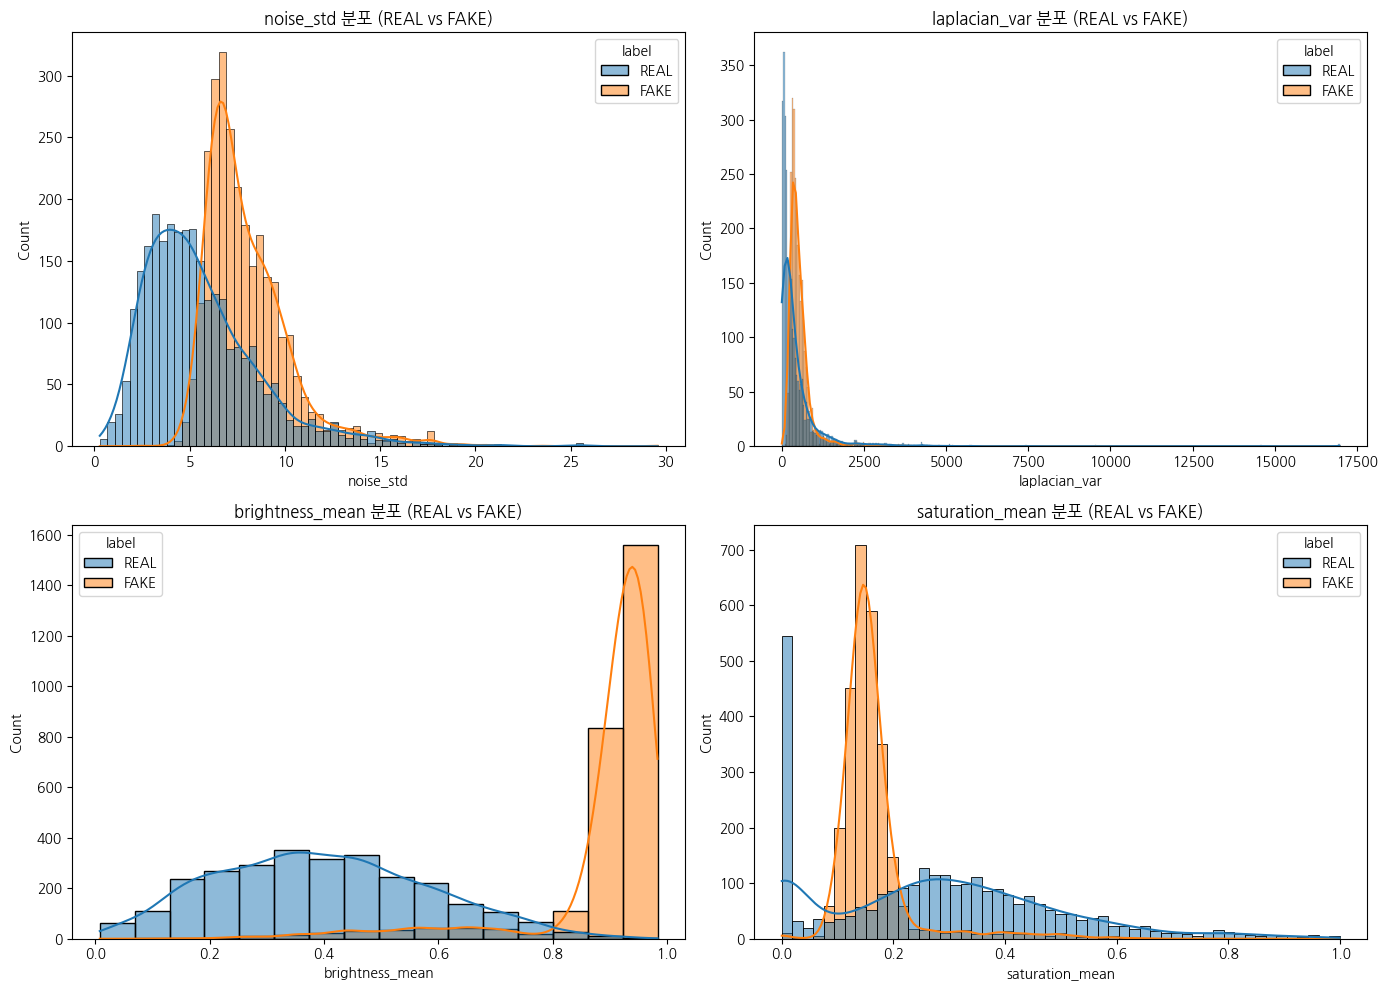

In [ ]:
# 주요 피쳐의 REAL/FAKE 분포 비교
feature_cols = ['noise_std', 'laplacian_var', 'brightness_mean', 'saturation_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(data=df, x=col, hue='label', ax=ax, kde=True)
    ax.set_title(f'{col} 분포 (REAL vs FAKE)')
plt.tight_layout()
plt.savefig('./output/feature_distribution.png')
plt.show()


In [ ]:
# 추출된 피쳐 전체 저장
# 다시 실행할 때 시간이 오래 걸리는 피쳐 추출 과정을 건너뛸 수 있음
df.to_csv('./output/df_all_features.csv', index=False)
print('저장 완료')


저장 완료


In [ ]:
# 저장했던 피쳐 데이터 불러오기
df = pd.read_csv('./output/df_all_features.csv')
df.head()


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,...,edge_std,edge_density,lbp_contrast,brightness_mean,brightness_std,saturation_mean,saturation_std,hue_std,color_entropy,warm_cool_ratio
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,...,47.847889,0.105047,8.110382,0.491342,0.298517,0.343336,0.190323,0.098586,5.812989,1.475714
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,...,26.580748,0.054522,2.058393,0.194918,0.237317,0.196550,0.184684,0.025374,4.620081,1.153400
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,...,36.745396,0.098937,4.338987,0.501947,0.325312,0.269341,0.160981,0.083469,5.843135,1.226040
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,...,55.333649,0.072957,5.686241,0.443334,0.325580,0.524999,0.251742,0.100670,5.620823,1.436507
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,...,40.697876,0.079167,5.402339,0.527654,0.275086,0.225926,0.191582,0.091397,5.760978,0.984184


# 데이터셋 분리
- 학습데이터: 80%
- 테스트데이터: 20%


In [ ]:
# 싸이킷런의 데이터 분리 모듈 가져오기
from sklearn.model_selection import train_test_split


In [ ]:
# df의 행의 수
df.shape


(5557, 43)

In [ ]:
df.columns


Index(['image_id', 'image_url', 'label', 'label_numeric', 'category', 'gender',
       'age_group', 'source', 'fake_method', 'image_quality', 'resolution',
       'confidence_score', 'detection_difficulty', 'dataset_split',
       'date_collected', 'version', 'year', 'local_path', 'rg_corr', 'rb_corr',
       'gb_corr', 'r_std', 'g_std', 'b_std', 'rg_diff_std', 'rb_diff_std',
       'gb_diff_std', 'noise_std', 'noise_energy', 'noise_kurtosis',
       'noise_snr', 'laplacian_var', 'edge_mean', 'edge_std', 'edge_density',
       'lbp_contrast', 'brightness_mean', 'brightness_std', 'saturation_mean',
       'saturation_std', 'hue_std', 'color_entropy', 'warm_cool_ratio'],
      dtype='object')

In [ ]:
# 학습데이터와 테스트 데이터로 분리
# stratify=df['label_numeric']: REAL/FAKE 비율을 학습/테스트에 동일하게 유지
train_df, test_df = train_test_split(df, test_size=0.2, random_state=1, stratify=df['label_numeric'])


In [ ]:
# 학습데이터
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4445 entries, 4903 to 1298
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              4445 non-null   int64  
 1   image_url             4445 non-null   object 
 2   label                 4445 non-null   object 
 3   label_numeric         4445 non-null   int64  
 4   category              4445 non-null   object 
 5   gender                4445 non-null   object 
 6   age_group             4445 non-null   object 
 7   source                4445 non-null   object 
 8   fake_method           2213 non-null   object 
 9   image_quality         4445 non-null   object 
 10  resolution            4445 non-null   object 
 11  confidence_score      4445 non-null   float64
 12  detection_difficulty  4445 non-null   object 
 13  dataset_split         4445 non-null   object 
 14  date_collected        4445 non-null   object 
 15  version               4

In [ ]:
# 테스트 데이터
test_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1112 entries, 2621 to 2646
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              1112 non-null   int64  
 1   image_url             1112 non-null   object 
 2   label                 1112 non-null   object 
 3   label_numeric         1112 non-null   int64  
 4   category              1112 non-null   object 
 5   gender                1112 non-null   object 
 6   age_group             1112 non-null   object 
 7   source                1112 non-null   object 
 8   fake_method           554 non-null    object 
 9   image_quality         1112 non-null   object 
 10  resolution            1112 non-null   object 
 11  confidence_score      1112 non-null   float64
 12  detection_difficulty  1112 non-null   object 
 13  dataset_split         1112 non-null   object 
 14  date_collected        1112 non-null   object 
 15  version               1

In [ ]:
# 학습데이터와 테스트 데이터 저장하기
# 분리를 다시 하면 학습데이터와 테스트 데이터는 바뀌기 때문에 일관된 결과를 얻기 위해서는
# 한번 분리한 데이터를 저장해서 계속 사용하는 것이 좋음
train_df.to_csv('./output/train_df.csv', index=False)
test_df.to_csv('./output/test_df.csv', index=False)


In [ ]:
# 저장했던 데이터 불러오기
train_df = pd.read_csv('./output/train_df.csv')
test_df  = pd.read_csv('./output/test_df.csv')


# 의사결정나무 모델만들기(1차)


In [ ]:
# 싸이킷런의 의사결정나무 불러오기
from sklearn.tree import DecisionTreeClassifier, plot_tree
# 모델 평가지표 계산 함수 불러오기
from sklearn.metrics import balanced_accuracy_score, classification_report


In [ ]:
train_df.columns


Index(['image_id', 'image_url', 'label', 'label_numeric', 'category', 'gender',
       'age_group', 'source', 'fake_method', 'image_quality', 'resolution',
       'confidence_score', 'detection_difficulty', 'dataset_split',
       'date_collected', 'version', 'year', 'local_path', 'rg_corr', 'rb_corr',
       'gb_corr', 'r_std', 'g_std', 'b_std', 'rg_diff_std', 'rb_diff_std',
       'gb_diff_std', 'noise_std', 'noise_energy', 'noise_kurtosis',
       'noise_snr', 'laplacian_var', 'edge_mean', 'edge_std', 'edge_density',
       'lbp_contrast', 'brightness_mean', 'brightness_std', 'saturation_mean',
       'saturation_std', 'hue_std', 'color_entropy', 'warm_cool_ratio'],
      dtype='object')

In [ ]:
# 타겟과 피쳐 이름 정리
target_name   = 'label_numeric'
feature_names = [
    'rg_corr', 'rb_corr', 'gb_corr', 'r_std', 'g_std', 'b_std',
    'rg_diff_std', 'rb_diff_std', 'gb_diff_std',
    'noise_std', 'noise_energy', 'noise_kurtosis', 'noise_snr',
    'laplacian_var', 'edge_mean', 'edge_std', 'edge_density', 'lbp_contrast',
    'brightness_mean', 'brightness_std', 'saturation_mean', 'saturation_std',
    'hue_std', 'color_entropy', 'warm_cool_ratio'
]


In [ ]:
# 학습데이터와 테스트 데이터의 피쳐, 타겟 데이터 프레임 만들기
train_x = train_df[feature_names]
train_y = train_df[target_name]

test_x = test_df[feature_names]
test_y = test_df[target_name]


In [ ]:
# 모델 저장 및 조건부 불러오기
# 이미 저장된 모델이 있으면 훈련을 건너뛰고 바로 불러옴
# → 런타임 재시작 후에도 재훈련 없이 이어서 작업 가능
import joblib, os

model_path = './output/cls_model.pkl'
if os.path.exists(model_path):
    cls_model = joblib.load(model_path)
    print('저장된 모델 불러오기 완료')
else:
    cls_model = DecisionTreeClassifier(max_depth=3, random_state=1)
    cls_model.fit(train_x, train_y)
    joblib.dump(cls_model, model_path)
    print('모델 훈련 및 저장 완료')


저장된 모델 불러오기 완료


In [ ]:
# 아래 셀은 위 셀에서 조건부 로드로 통합되었습니다.
# cls_model = joblib.load('./output/cls_model.pkl')


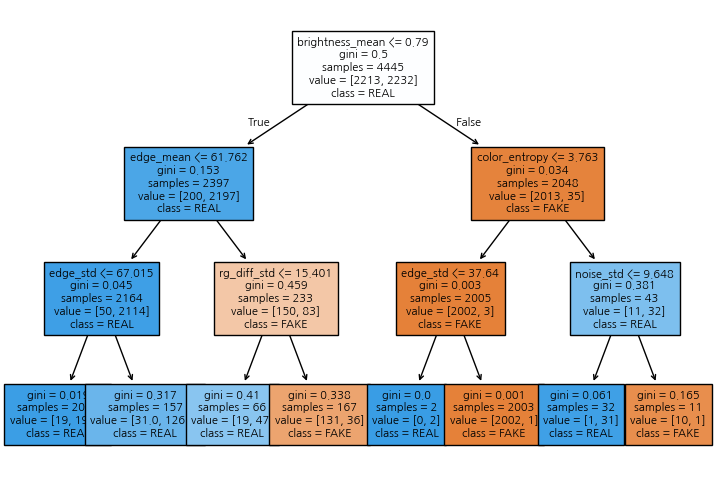

In [ ]:
plt.figure(figsize=(9, 6))
plot_tree(cls_model, feature_names=train_x.columns, class_names=['FAKE','REAL'],
          filled=True, impurity=True, fontsize=8)
plt.savefig('./output/deepfake_cls_DT.png')
plt.show()


In [ ]:
# 의사결정나무 모형 결과의 텍스트 표현
from sklearn import tree
cls_text_tree = tree.export_text(cls_model, feature_names=list(train_x.columns))
print(cls_text_tree)


|--- brightness_mean <= 0.79
|   |--- edge_mean <= 61.76
|   |   |--- edge_std <= 67.02
|   |   |   |--- class: 1
|   |   |--- edge_std >  67.02
|   |   |   |--- class: 1
|   |--- edge_mean >  61.76
|   |   |--- rg_diff_std <= 15.40
|   |   |   |--- class: 1
|   |   |--- rg_diff_std >  15.40
|   |   |   |--- class: 0
|--- brightness_mean >  0.79
|   |--- color_entropy <= 3.76
|   |   |--- edge_std <= 37.64
|   |   |   |--- class: 1
|   |   |--- edge_std >  37.64
|   |   |   |--- class: 0
|   |--- color_entropy >  3.76
|   |   |--- noise_std <= 9.65
|   |   |   |--- class: 1
|   |   |--- noise_std >  9.65
|   |   |   |--- class: 0



In [ ]:
# 피쳐 중요도
cls_model.feature_importances_


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.01140272, 0.        , 0.        , 0.00616708,
       0.        , 0.        , 0.        , 0.        , 0.07922141,
       0.00698186, 0.        , 0.        , 0.8735261 , 0.        ,
       0.        , 0.        , 0.        , 0.02270083, 0.        ])

In [ ]:
# 중요도를 데이터 프레임으로 변환하고, 내림차순 정렬
cls_model_imp = pd.DataFrame(
    cls_model.feature_importances_,
    index=test_x.columns,
    columns=['importance']
).sort_values(by='importance', ascending=False)
cls_model_imp.head()


,importance
brightness_mean,0.873526
edge_mean,0.079221
color_entropy,0.022701
rg_diff_std,0.011403
edge_std,0.006982


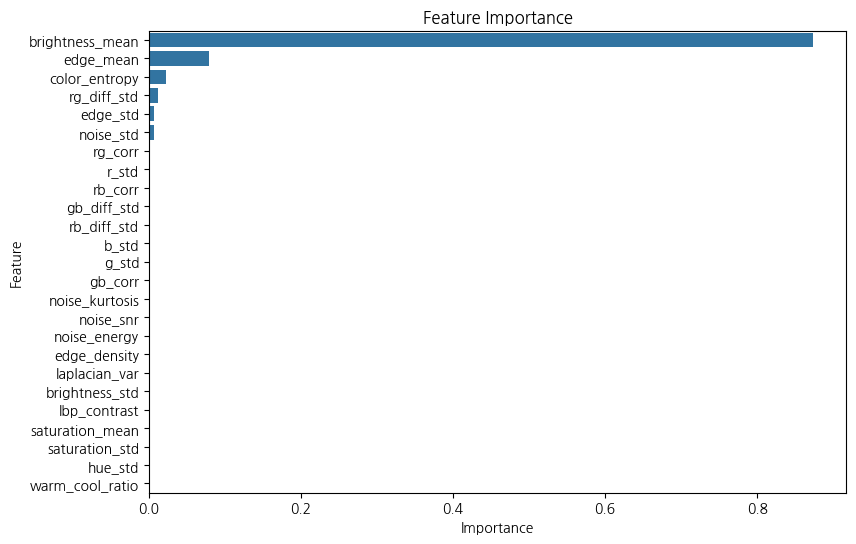

In [ ]:
# 피쳐 중요도 시각화
plt.figure(figsize=(9, 6))
sns.barplot(data=cls_model_imp, x='importance', y=cls_model_imp.index, orient='h')
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.savefig('./output/feature_importance_1st.png')
plt.show()


### 1차 성능 테스트


In [ ]:
# 학습데이터 예측 결과
predict_train = cls_model.predict(train_x)
predict_train[0:5]


array([0, 0, 0, 0, 1])

In [ ]:
# 학습데이터의 실제값(train_y)과 예측값(predict_train)을 데이터 프레임으로 만들기
df_train = pd.DataFrame({'실제값': train_y, '예측값': predict_train})
df_train.head()


,실제값,예측값
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1


In [ ]:
# 학습데이터 성능 평가
train_bal_acc = balanced_accuracy_score(train_y, predict_train)
print(f'학습데이터 Balanced Accuracy = {train_bal_acc:.4f}')
print(classification_report(train_y, predict_train, target_names=['FAKE','REAL']))


학습데이터 Balanced Accuracy = 0.9757
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.98      2213
        REAL       0.97      0.98      0.98      2232

    accuracy                           0.98      4445
   macro avg       0.98      0.98      0.98      4445
weighted avg       0.98      0.98      0.98      4445



In [ ]:
# 테스트 데이터로 예측
predict_test = cls_model.predict(test_x)

# 테스트데이터의 실제값(test_y)과 예측값(predict_test)을 데이터 프레임으로 만들기
df_test = pd.DataFrame({'실제값': test_y, '예측값': predict_test})
df_test.head()


,실제값,예측값
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1


In [ ]:
# 테스트데이터 성능 평가
test_bal_acc = balanced_accuracy_score(test_y, predict_test)
print(f'테스트 데이터 Balanced Accuracy = {test_bal_acc:.4f}')
print(classification_report(test_y, predict_test, target_names=['FAKE','REAL']))


테스트 데이터 Balanced Accuracy = 0.9712
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.97       554
        REAL       0.97      0.98      0.97       558

    accuracy                           0.97      1112
   macro avg       0.97      0.97      0.97      1112
weighted avg       0.97      0.97      0.97      1112



In [ ]:
# 1차 모델 성능 정리
result_1st = pd.DataFrame(
    {'Train': [train_bal_acc], 'Test': [test_bal_acc]},
    index=['Balanced Accuracy']
)
result_1st


,Train,Test
Balanced Accuracy,0.975672,0.971203


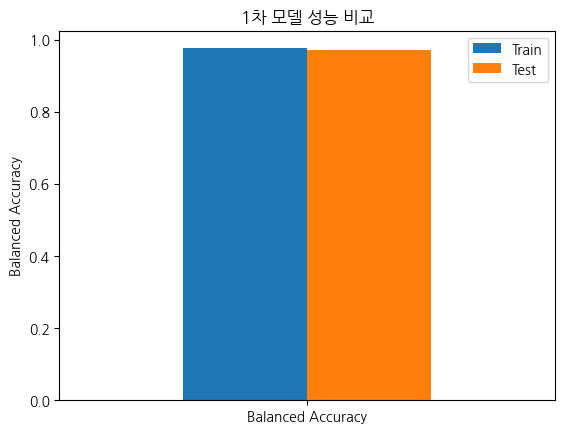

In [ ]:
result_1st.plot(kind='bar')
plt.title('1차 모델 성능 비교')
plt.ylabel('Balanced Accuracy')
plt.xticks(rotation=0)
plt.savefig('./output/deepfake_1st_model_performance.png')
plt.show()


# HPO
- K-fold 교차 검증을 이용하여 최적 하이퍼 파라미터 찾기
- balanced_accuracy가 가장 높은 하이퍼파라미터 조합 찾기
- 의사결정나무의 주요 하이퍼 파라미터
- DecisionTreeClassifier의 주요 하이퍼 파라미터
  - criterion{"gini", "entropy"}, default="gini"
  - splitter{"best", "random"}, default="best"
  - max_depth, int, default=None
  - min_samples_split, int or float, default=2
  - min_samples_leaf, int or float, default=1
  - max_features, int, float or {"auto", "sqrt", "log2"}, default=None
  - random_state, int, default=None
  - class_weight, dict or "balanced", default=None
  - ccp_alpha, non-negative float, default=0.0

- 모델 평가 지표 이름들
  -  https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter  


In [ ]:
# GridSearchCV: n_jobs=-1 로 모든 CPU 코어 병렬 사용
# → 코랩 기본 2코어 기준 약 2배 빠름
from sklearn.model_selection import GridSearchCV

model = DecisionTreeClassifier(random_state=1)

# 파라미터를 딕셔너리 형태로 저장
params = {
    'criterion':        ['gini', 'entropy'],
    'splitter':         ['best', 'random'],
    'max_depth':        list(range(2, 15)),
    'min_samples_leaf': list(range(2, 5)),
    'class_weight':     [None, 'balanced'],
}

# GridSearchCV 객체 생성
# n_jobs=-1: 가용 CPU 코어 전부 사용 (병렬처리)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)
grid_search.fit(train_x, train_y)
print('GridSearchCV 완료')


GridSearchCV 완료


In [ ]:
# joblib은 위 셀들에서 이미 import 되었으므로 생략 가능
# import joblib  # 이미 import 됨


In [ ]:
# HPO 결과 조건부 저장/불러오기
# 이미 탐색 결과가 저장되어 있으면 재탐색 없이 불러옴
hpo_path = './output/grid_search_deepfake_dt.pkl'
if os.path.exists(hpo_path):
    grid_search = joblib.load(hpo_path)
    print('저장된 HPO 결과 불러오기 완료')
else:
    joblib.dump(grid_search, hpo_path)
    print('HPO 결과 저장 완료')


저장된 HPO 결과 불러오기 완료


In [ ]:
# 그리드 서치 결과 확인
hpo_result = pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score')
hpo_result.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_min_samples_leaf,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
182,0.170045,0.031928,0.006376,0.001606,balanced,gini,6,3,best,"{'class_weight': 'balanced', 'criterion': 'gin...",0.971905,0.973003,0.976366,0.970740,0.977464,0.973896,0.002591,1
28,0.108040,0.011042,0.003786,0.000091,None,gini,6,4,best,"{'class_weight': None, 'criterion': 'gini', 'm...",0.973011,0.974124,0.971874,0.970727,0.978583,0.973664,0.002708,2
180,0.195001,0.031280,0.007512,0.002233,balanced,gini,6,2,best,"{'class_weight': 'balanced', 'criterion': 'gin...",0.975276,0.971882,0.976366,0.968503,0.974083,0.973222,0.002790,3
24,0.101520,0.005179,0.003780,0.000113,None,gini,6,2,best,"{'class_weight': None, 'criterion': 'gini', 'm...",0.973026,0.971882,0.977495,0.968490,0.975202,0.973219,0.003046,4
184,0.147983,0.035548,0.005560,0.002023,balanced,gini,6,4,best,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978646,0.971874,0.971874,0.965147,0.977464,0.973001,0.004817,5


In [ ]:
# 조합마다 평균 성능평가 지표(balanced_accuracy), 값이 클수록 성능이 좋음
hpo_result['mean_test_score'].describe()


,mean_test_score
count,312.000000
mean,0.967002
std,0.004846
min,0.946449
25%,0.966461
50%,0.968046
75%,0.969617
max,0.973896


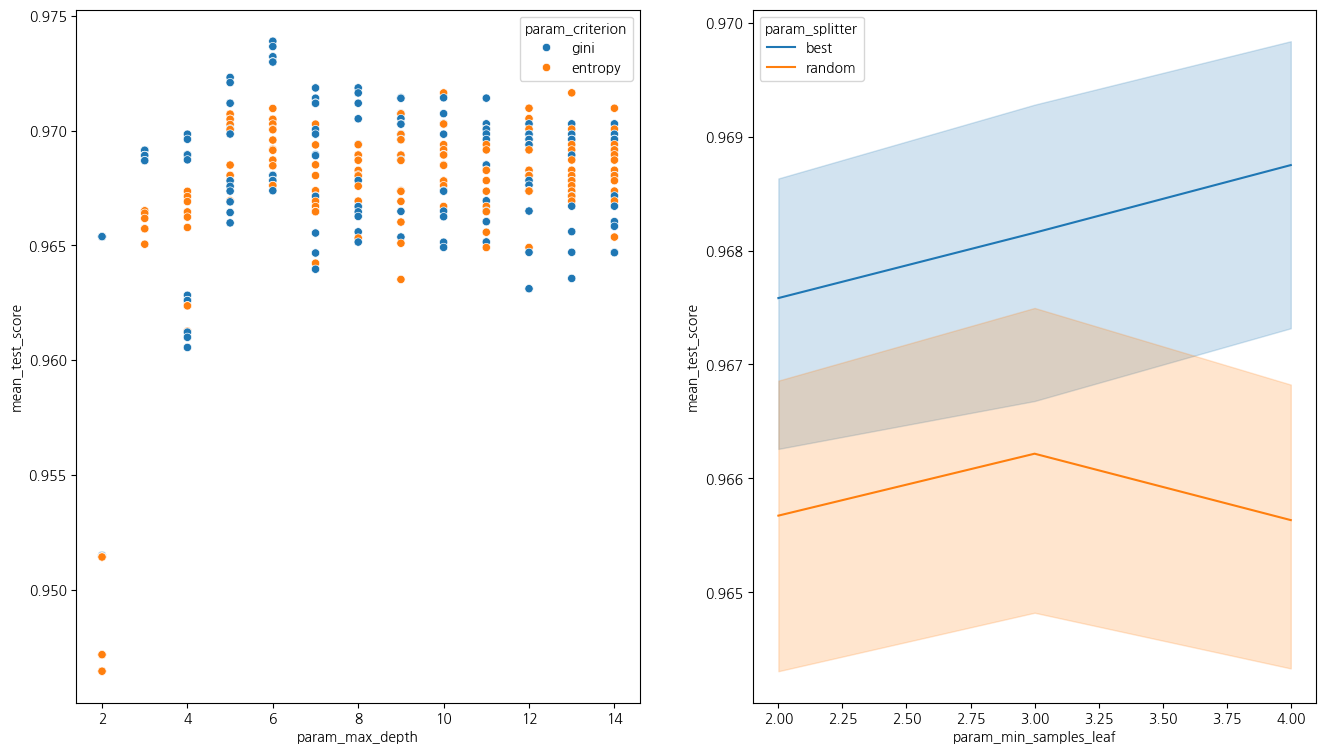

In [ ]:
# 하이퍼 파라미터와 balanced_accuracy 관계 보기
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
sns.scatterplot(data=hpo_result, x='param_max_depth', y='mean_test_score', hue='param_criterion')

plt.subplot(1, 2, 2)
sns.lineplot(data=hpo_result, x='param_min_samples_leaf', y='mean_test_score', hue='param_splitter')

plt.savefig('./output/deepfake_grid_search.png')
plt.show()


In [ ]:
# 가장 순위가 높은, 즉 balanced_accuracy가 가장 높은 하이퍼 파라미터 조합보기
grid_search.best_params_


{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 6,
 'min_samples_leaf': 3,
 'splitter': 'best'}

# Final model
- 그리드 서치로 찾은 최적의 하이퍼 파라미터 조합으로 최종 모델을 만듦



In [ ]:
# 그리드 서치로 찾은 최적의 하이퍼 파라미터 조합 모델이 최종모델이며 final_model에 저장
final_model = grid_search.best_estimator_
final_model


DecisionTreeClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=3,
                       random_state=1)

In [ ]:
# 최종 모델 조건부 저장/불러오기
final_path = './output/final_dt_deepfake.pkl'
if os.path.exists(final_path):
    final_model = joblib.load(final_path)
    print('저장된 최종 모델 불러오기 완료')
else:
    final_model = grid_search.best_estimator_
    joblib.dump(final_model, final_path)
    print('최종 모델 저장 완료')


저장된 최종 모델 불러오기 완료


In [ ]:
# 아래 셀은 위 셀에서 조건부 로드로 통합되었습니다.
# final_model = joblib.load('./output/final_dt_deepfake.pkl')


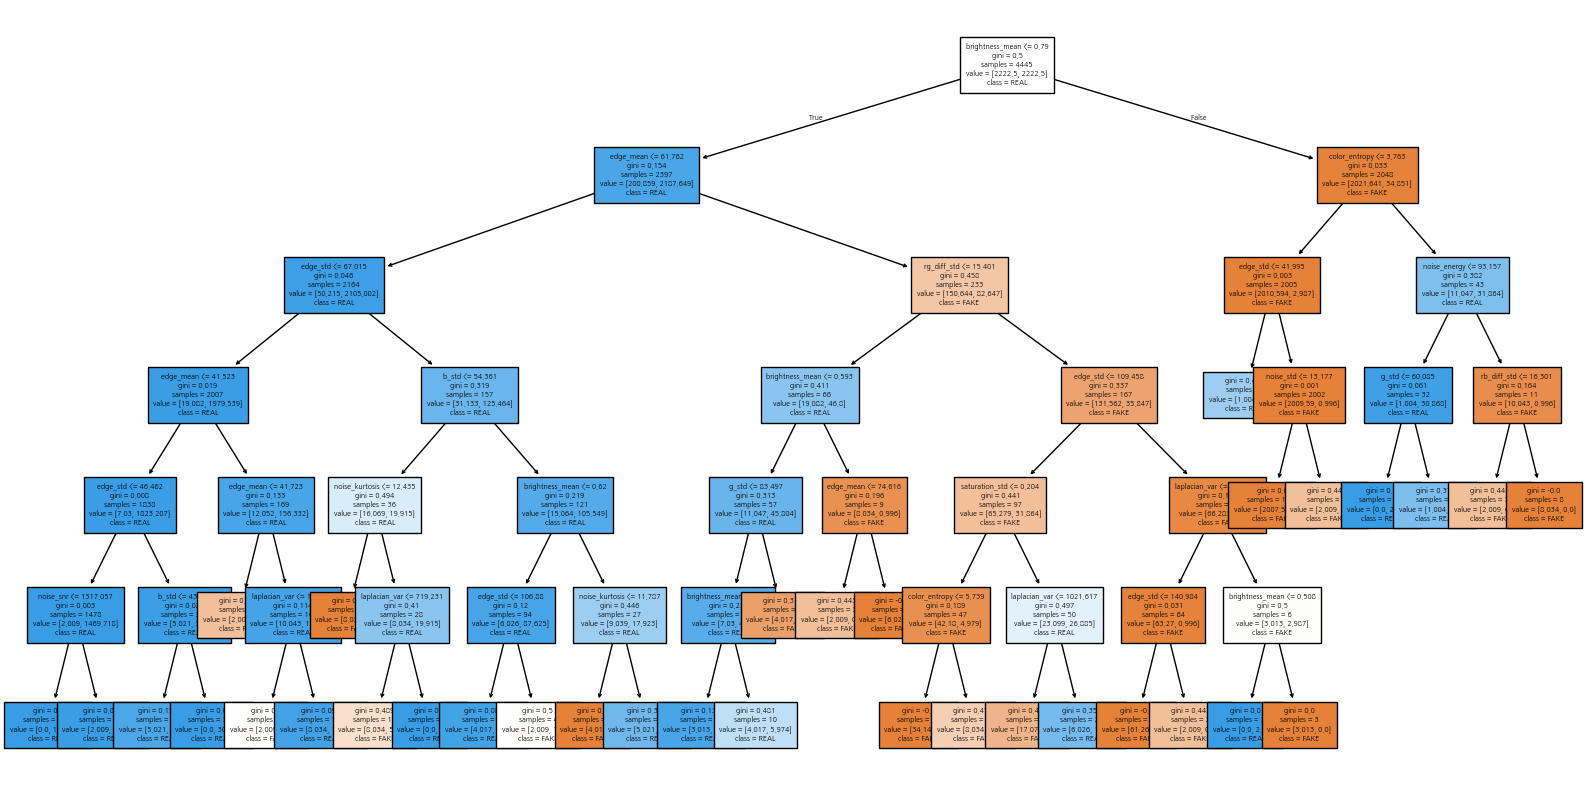

In [ ]:
# 의사결정나무 실행 결과의 시각적 표현
# 왼쪽으로 뻗어나가는 가지가 조건 = Yes, 오른쪽이 조건 = No
plt.figure(figsize=(20, 10))
plot_tree(final_model, feature_names=train_x.columns, class_names=['FAKE','REAL'],
          fontsize=5, filled=True, impurity=True)
plt.savefig('./output/deepfake_final_model.png')
plt.show()


In [ ]:
# 의사결정나무 모형 결과의 텍스트 표현
from sklearn import tree
cls_text_tree = tree.export_text(final_model, feature_names=list(train_x.columns))
print(cls_text_tree)


|--- brightness_mean <= 0.79
|   |--- edge_mean <= 61.76
|   |   |--- edge_std <= 67.02
|   |   |   |--- edge_mean <= 41.52
|   |   |   |   |--- edge_std <= 46.46
|   |   |   |   |   |--- noise_snr <= 1317.06
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- noise_snr >  1317.06
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- edge_std >  46.46
|   |   |   |   |   |--- b_std <= 44.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- b_std >  44.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- edge_mean >  41.52
|   |   |   |   |--- edge_mean <= 41.72
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- edge_mean >  41.72
|   |   |   |   |   |--- laplacian_var <= 184.18
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- laplacian_var >  184.18
|   |   |   |   |   |   |--- class: 1
|   |   |--- edge_std >  67.02
|   |   |   |--- b_std <= 54.36
|   |   |   |   |--- noise_kurtosis <= 12.44
|   |   |   |   |   |--- class: 0
|   |   

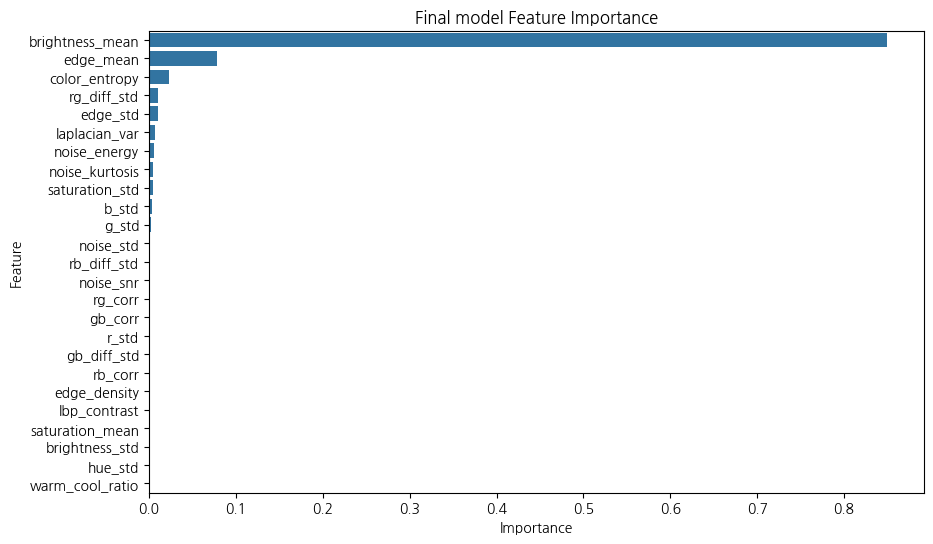

In [ ]:
# 최종모델의 피쳐 중요도
imp_tbl_final = pd.DataFrame(
    final_model.feature_importances_,
    index=test_x.columns,
    columns=['importance']
)
imp_tbl_final.sort_values('importance', ascending=False, inplace=True)
imp_tbl_final

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_tbl_final, x='importance', y=imp_tbl_final.index, orient='h')
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.title('Final model Feature Importance')
plt.savefig('./output/feature_importance_final.png')
plt.show()


# 성능평가


In [ ]:
# 테스트 데이터의 예측값 계산
final_predict_test = final_model.predict(test_x)
final_predict_test[0:5]


array([1, 0, 1, 1, 1])

In [ ]:
# balanced_accuracy 계산
final_bal_acc = balanced_accuracy_score(test_y, final_predict_test)
print(f'최종모델의 Balanced Accuracy: {final_bal_acc:.4f}')


최종모델의 Balanced Accuracy: 0.9649


In [ ]:
# 실제 값과 비교하기 위한 데이터 프레임을 만듦
test_result = test_df.copy()
test_result['예측_label_numeric'] = final_predict_test
test_result['예측_정답여부'] = (test_result['label_numeric'] == test_result['예측_label_numeric']).astype(int)
test_result.head()


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,...,lbp_contrast,brightness_mean,brightness_std,saturation_mean,saturation_std,hue_std,color_entropy,warm_cool_ratio,예측_label_numeric,예측_정답여부
0,2622,https://images.unsplash.com/photo-161635606104...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,...,4.985383,0.391137,0.172263,0.554572,0.300502,0.189078,5.400308,0.796630,1,1
1,5382,https://api.dicebear.com/7.x/personas/jpg?seed...,FAKE,0,AI Generated,Unknown,26-35,MultiSource,StyleGAN3,Medium,...,8.135867,0.911608,0.177042,0.147353,0.247412,0.175093,2.948251,0.975503,0,1
2,1270,https://images.unsplash.com/photo-161123265840...,REAL,1,Authentic,Unknown,26-35,Unsplash,NaN,High,...,4.611050,0.365274,0.300097,0.302717,0.207491,0.069489,5.570039,1.151593,1,1
3,1033,https://images.unsplash.com/photo-175861196962...,REAL,1,Authentic,Male,26-35,Unsplash,NaN,Medium,...,2.068270,0.756392,0.136934,0.276137,0.202446,0.112983,5.427986,1.267826,1,1
4,44,https://images.unsplash.com/photo-164705850631...,REAL,1,Authentic,Unknown,18-25,Unsplash,NaN,High,...,5.034407,0.524621,0.324425,0.257100,0.205042,0.093090,5.805740,1.285228,1,1


# 모델 해석 및 결론
- 예측 정확도 차이가 많이 나는 피쳐에 대한 탐색


In [ ]:
# label별 정답률
test_result.groupby('label')['예측_정답여부'].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,554.0,0.962094,0.191142,0.0,1.0,1.0,1.0,1.0
REAL,558.0,0.967742,0.176843,0.0,1.0,1.0,1.0,1.0


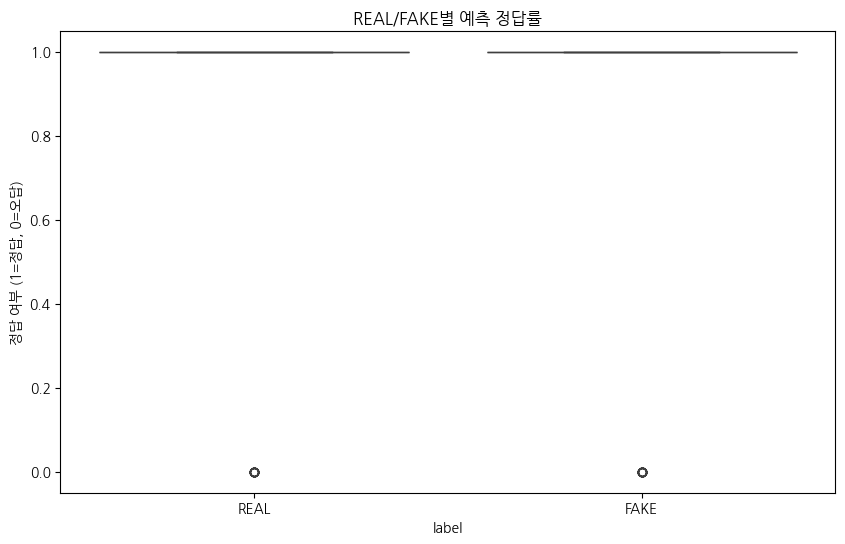

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_result, x='label', y='예측_정답여부')
plt.title('REAL/FAKE별 예측 정답률')
plt.xlabel('label')
plt.ylabel('정답 여부 (1=정답, 0=오답)')
plt.savefig('./output/deepfake_label별_정답률.png')
plt.show()


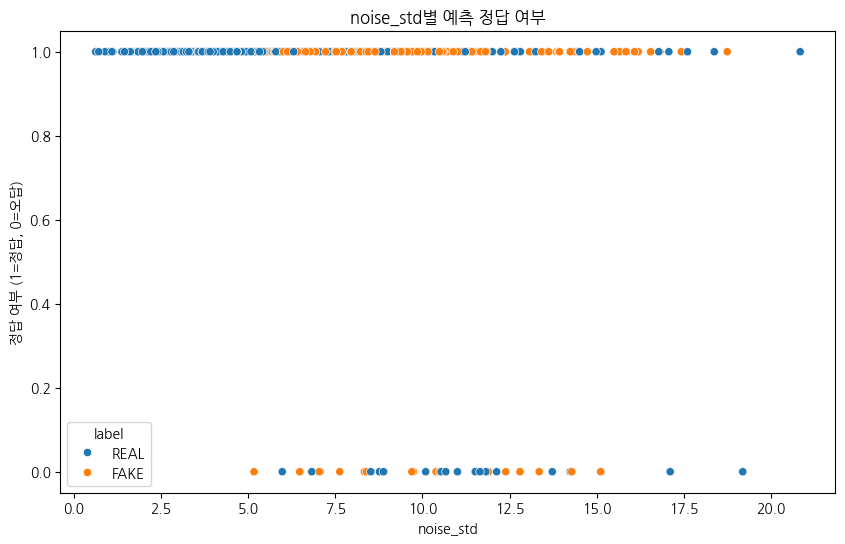

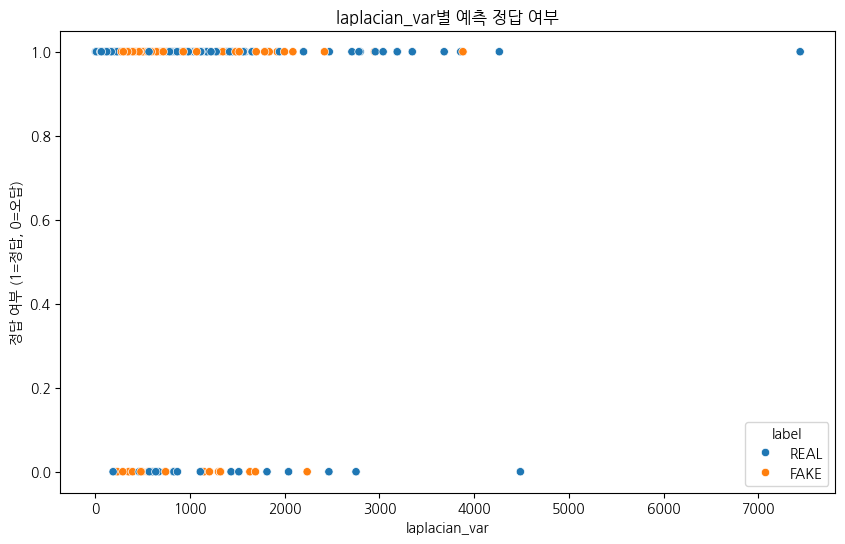

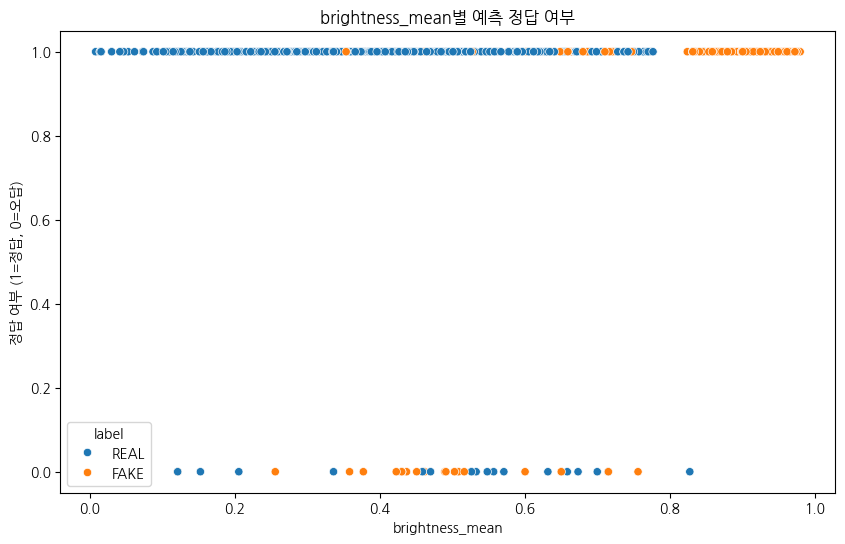

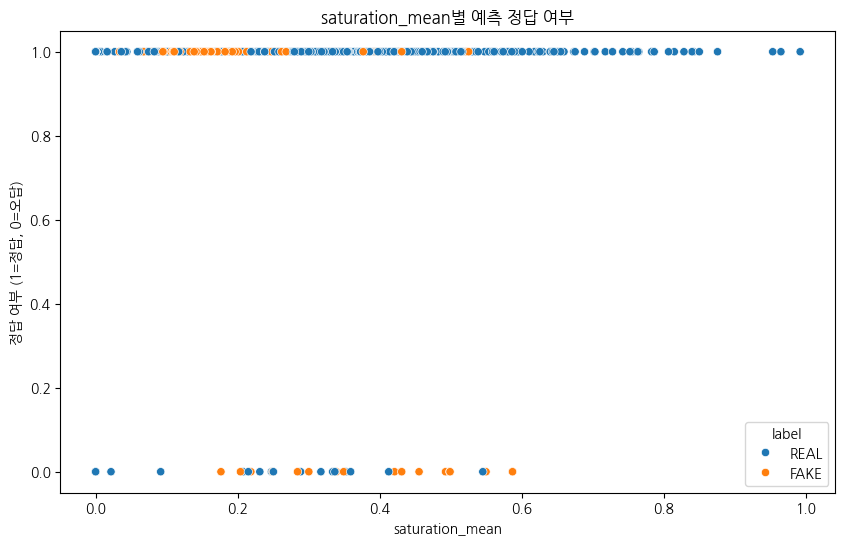

In [ ]:
# 주요 피쳐별 정답 여부 분포
# 기존: 피쳐마다 동일한 코드를 4번 반복 → 반복문으로 통합
# 효과: 코드 길이 1/4로 단축, 피쳐 추가 시 확장 용이
feature_groups = ['noise_std', 'laplacian_var', 'brightness_mean', 'saturation_mean']

for feat in feature_groups:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=test_result, x=feat, y='예측_정답여부', hue='label')
    plt.title(f'{feat}별 예측 정답 여부')
    plt.xlabel(feat)
    plt.ylabel('정답 여부 (1=정답, 0=오답)')
    plt.savefig(f'./output/deepfake_scatter_{feat}.png')
    plt.show()


In [ ]:
# 아래 셀은 위 셀에서 반복문으로 통합되었습니다.
# (기존 코드: 피쳐마다 동일한 코드를 4회 반복 → 위 셀로 대체)


In [ ]:
# 예측결과 저장하기
test_result.to_csv('./output/test_result.csv', index=False)


In [ ]:
# 예측결과 불러오기
test_result = pd.read_csv('./output/test_result.csv')
test_result.head()


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,...,lbp_contrast,brightness_mean,brightness_std,saturation_mean,saturation_std,hue_std,color_entropy,warm_cool_ratio,예측_label_numeric,예측_정답여부
0,2622,https://images.unsplash.com/photo-161635606104...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,...,4.985383,0.391137,0.172263,0.554572,0.300502,0.189078,5.400308,0.796630,1,1
1,5382,https://api.dicebear.com/7.x/personas/jpg?seed...,FAKE,0,AI Generated,Unknown,26-35,MultiSource,StyleGAN3,Medium,...,8.135867,0.911608,0.177042,0.147353,0.247412,0.175093,2.948251,0.975503,0,1
2,1270,https://images.unsplash.com/photo-161123265840...,REAL,1,Authentic,Unknown,26-35,Unsplash,NaN,High,...,4.611050,0.365274,0.300097,0.302717,0.207491,0.069489,5.570039,1.151593,1,1
3,1033,https://images.unsplash.com/photo-175861196962...,REAL,1,Authentic,Male,26-35,Unsplash,NaN,Medium,...,2.068270,0.756392,0.136934,0.276137,0.202446,0.112983,5.427986,1.267826,1,1
4,44,https://images.unsplash.com/photo-164705850631...,REAL,1,Authentic,Unknown,18-25,Unsplash,NaN,High,...,5.034407,0.524621,0.324425,0.257100,0.205042,0.093090,5.805740,1.285228,1,1


In [ ]:
# 최종결과 변환 및 저장
!jupyter nbconvert --to html "/content/drive/MyDrive/ML_2601/term_paper_202155020/ML_2601_Deep_Fake.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/ML_2601/term_paper_202155020/ML_2601_Deep_Fake.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
         

# END
